# Clustering and Structure Discovery

**Course Title:** ENM 3800: Learning from Data

**Instructor:** Eva Dyer

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nerdslab/learningfromdata-course/blob/main/notebooks/Notebook_5/Notebook_5b_Clustering.ipynb)

Clustering is unsupervised learning for discovering structure. Unlike classification, there is usually no single correct answer. Different algorithms define "similar" in different ways, so the right method depends on the question and the geometry of the data.


## Overview

Clustering algorithms group observations based on descriptive features. They are often used for exploration, compression, search, subgroup discovery, and feature engineering.

A cluster should be treated as a modeling hypothesis, not a discovered fact. A useful question to keep asking is:

> What definition of similarity is this algorithm using?


In [1]:
#| code-fold: true
import numpy as np
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.cluster import KMeans, DBSCAN, MeanShift, SpectralClustering, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.datasets import make_blobs, make_moons, make_circles
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

np.random.seed(0)
plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

def show_data(X, label=None, centroids=None, cmap='tab10', colorbar=False, title=None, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(5.5, 5))
    scatter = ax.scatter(X[:, 0], X[:, 1], c=label, cmap=cmap, s=28, alpha=0.85)
    if colorbar:
        plt.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)
    if centroids is not None:
        ax.scatter(centroids[:, 0], centroids[:, 1], marker='*', c='black', s=180,
                   edgecolor='white', linewidth=0.8)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal', adjustable='box')
    if title:
        ax.set_title(title)
    return ax



## Centroid-based clustering: k-means

K-means works well when clusters are roughly spherical, similarly sized, and separated by mostly linear boundaries. It requires choosing $k$, the number of clusters.


/tmp/ipykernel_1134073/2489774336.py:19: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(X[:, 0], X[:, 1], c=label, cmap=cmap, s=28, alpha=0.85)


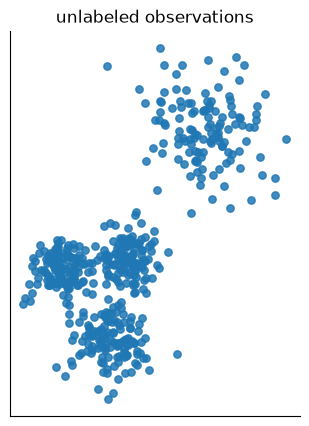

In [2]:
X, y_true = datasets.make_blobs(
    n_samples=500,
    n_features=2,
    centers=4,
    cluster_std=[2.0, 0.9, 1.2, 1.1],
    center_box=(-10.0, 10.0),
    random_state=1,
)
show_data(X, title='unlabeled observations')
plt.show()

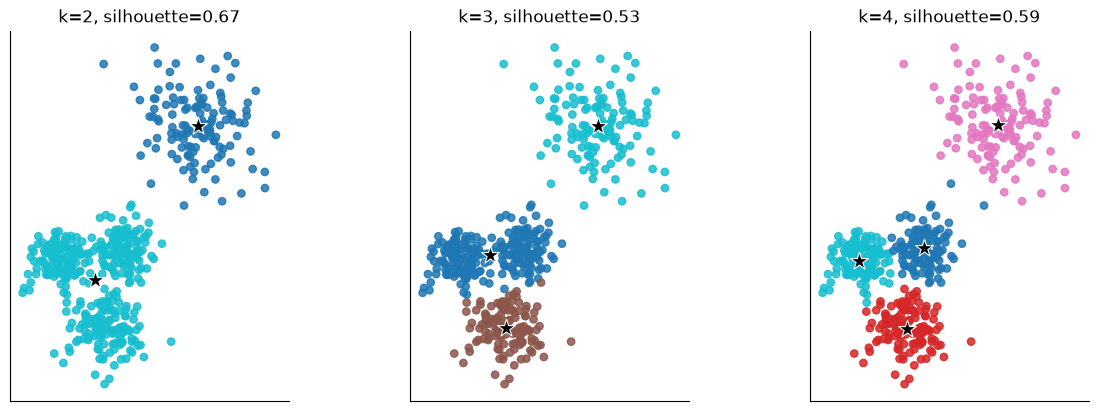

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
for ax, k in zip(axes, [2, 3, 4]):
    km = KMeans(n_clusters=k, n_init=10, random_state=0)
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels)
    show_data(X, labels, centroids=km.cluster_centers_, title=f'k={k}, silhouette={score:.2f}', ax=ax)
plt.show()

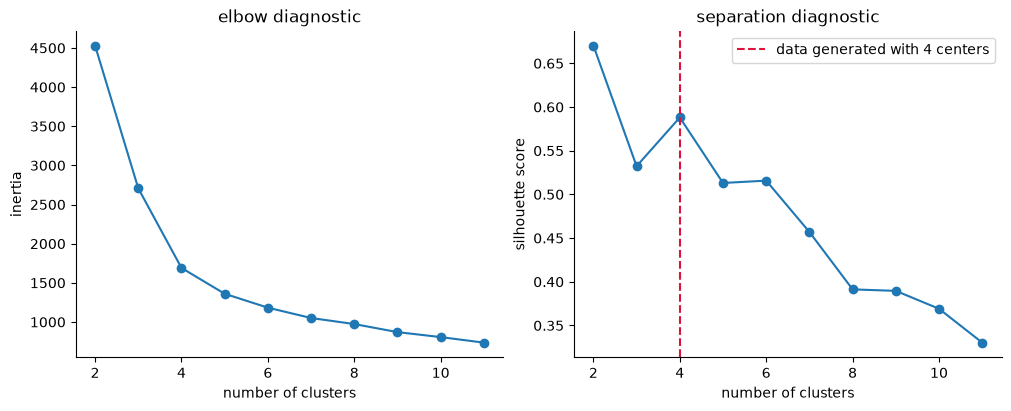

In [4]:
inertias = []
silhouette_scores = []
K = range(2, 12)

for k in K:
    km = KMeans(n_clusters=k, n_init=10, random_state=0)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
axes[0].plot(list(K), inertias, marker='o')
axes[0].set_xlabel('number of clusters')
axes[0].set_ylabel('inertia')
axes[0].set_title('elbow diagnostic')
axes[1].plot(list(K), silhouette_scores, marker='o')
axes[1].axvline(4, color='crimson', linestyle='--', label='data generated with 4 centers')
axes[1].set_xlabel('number of clusters')
axes[1].set_ylabel('silhouette score')
axes[1].set_title('separation diagnostic')
axes[1].legend()
plt.show()

In [5]:
def compare_kmeans_k(k=4):
    km = KMeans(n_clusters=k, n_init=10, random_state=0)
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels)
    show_data(X, labels, centroids=km.cluster_centers_, title=f'k={k}, silhouette={score:.2f}')
    plt.show()

try:
    import ipywidgets as widgets
    widgets.interact(compare_kmeans_k, k=widgets.IntSlider(value=4, min=2, max=10, step=1))
except Exception:
    compare_kmeans_k(k=4)

interactive(children=(IntSlider(value=4, description='k', max=10, min=2), Output()), _dom_classes=('widget-int…

### Exercise: choosing k is a modeling decision

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nerdslab/learningfromdata-course/blob/main/notebooks/Notebook_5/Notebook_5b_Clustering.ipynb#scrollTo=ex-choosing-k-modeling-decision)

Use the elbow plot, silhouette plot, and interactive visualization.

1. Which values of $k$ look defensible?
2. Which value would you choose if the goal were compression?
3. Which value would you choose if the goal were subgroup discovery?
4. What evidence would make you distrust the clusters?


## Gaussian mixture models

A Gaussian mixture model represents the data as a mixture of Gaussian distributions. Unlike k-means, it can represent elliptical clusters and soft membership probabilities.


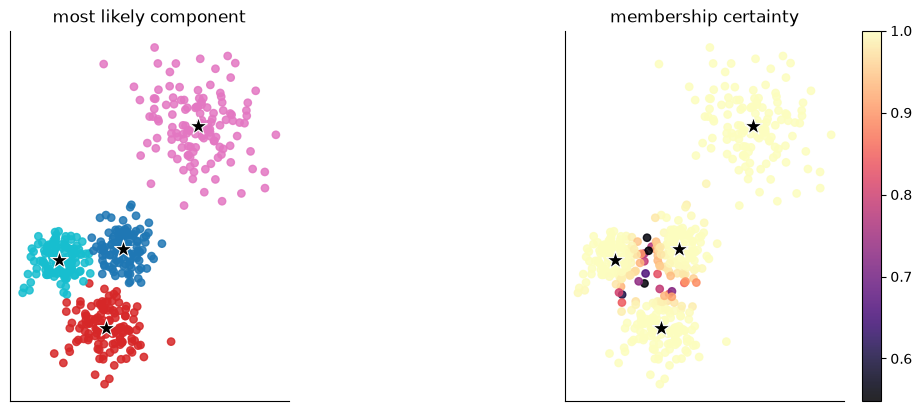

In [6]:
gmm = GaussianMixture(n_components=4, covariance_type='full', random_state=0)
gmm_labels = gmm.fit_predict(X)
responsibilities = gmm.predict_proba(X)
max_membership = responsibilities.max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
show_data(X, gmm_labels, centroids=gmm.means_, title='most likely component', ax=axes[0])
show_data(X, max_membership, centroids=gmm.means_, cmap='magma', colorbar=True,
          title='membership certainty', ax=axes[1])
plt.show()

### Discussion: hard labels vs soft membership

1. Where are the least certain points?
2. Why might soft membership be more honest than a single cluster label?
3. What real datasets might contain mixed membership rather than clean groups?


## Density-based clustering

Density-based methods define clusters as regions where points are packed closely together. DBSCAN can find curved clusters and mark some points as noise, but its results depend strongly on distance scale.


/tmp/ipykernel_1134073/2489774336.py:19: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(X[:, 0], X[:, 1], c=label, cmap=cmap, s=28, alpha=0.85)


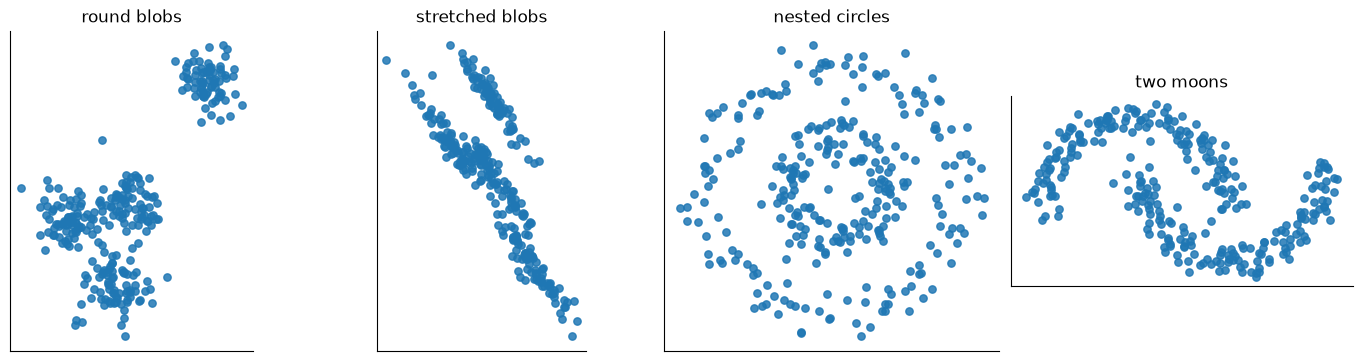

In [7]:
random_state = 1
N = 300
X_blobs, y_blobs = make_blobs(N, centers=4, random_state=random_state)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X_aniso = np.dot(X_blobs, transformation)
X_circles, y_circles = make_circles(N, noise=0.1, factor=0.4, random_state=random_state)
X_moons, y_moons = make_moons(N, noise=0.1, random_state=random_state)

datasets_to_compare = [
    ('round blobs', X_blobs),
    ('stretched blobs', X_aniso),
    ('nested circles', X_circles),
    ('two moons', X_moons),
]

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5), constrained_layout=True)
for ax, (title, data) in zip(axes, datasets_to_compare):
    show_data(data, title=title, ax=ax)
plt.show()

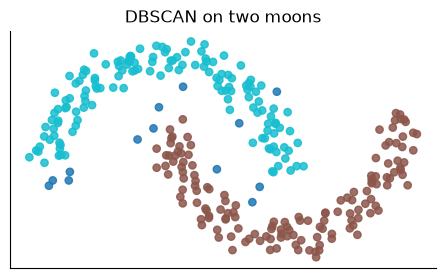

In [8]:
model = DBSCAN(eps=0.14, min_samples=5)
y_predict = model.fit_predict(X_moons)
show_data(X_moons, y_predict, title='DBSCAN on two moons')
plt.show()

In [9]:
def dbscan_parameter_demo(eps=0.14, min_samples=5):
    labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_moons)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)
    show_data(X_moons, labels, title=f'eps={eps:.2f}, min_samples={min_samples}, clusters={n_clusters}, noise={n_noise}')
    plt.show()

try:
    import ipywidgets as widgets
    widgets.interact(
        dbscan_parameter_demo,
        eps=widgets.FloatSlider(value=0.14, min=0.05, max=0.35, step=0.01),
        min_samples=widgets.IntSlider(value=5, min=2, max=20, step=1),
    )
except Exception:
    dbscan_parameter_demo(eps=0.14, min_samples=5)

interactive(children=(FloatSlider(value=0.14, description='eps', max=0.35, min=0.05, step=0.01), IntSlider(val…

### Exercise: density depends on scale

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nerdslab/learningfromdata-course/blob/main/notebooks/Notebook_5/Notebook_5b_Clustering.ipynb#scrollTo=ex-density-depends-scale)

Adjust `eps` and `min_samples`.

1. What happens when `eps` is too small?
2. What happens when `eps` is too large?
3. Why does DBSCAN need feature scaling before it is used on real multivariable data?


## Matching algorithms to data shapes

The same dataset can look very different depending on the clustering method. This is not a failure of clustering; it is the point. Each method encodes assumptions.


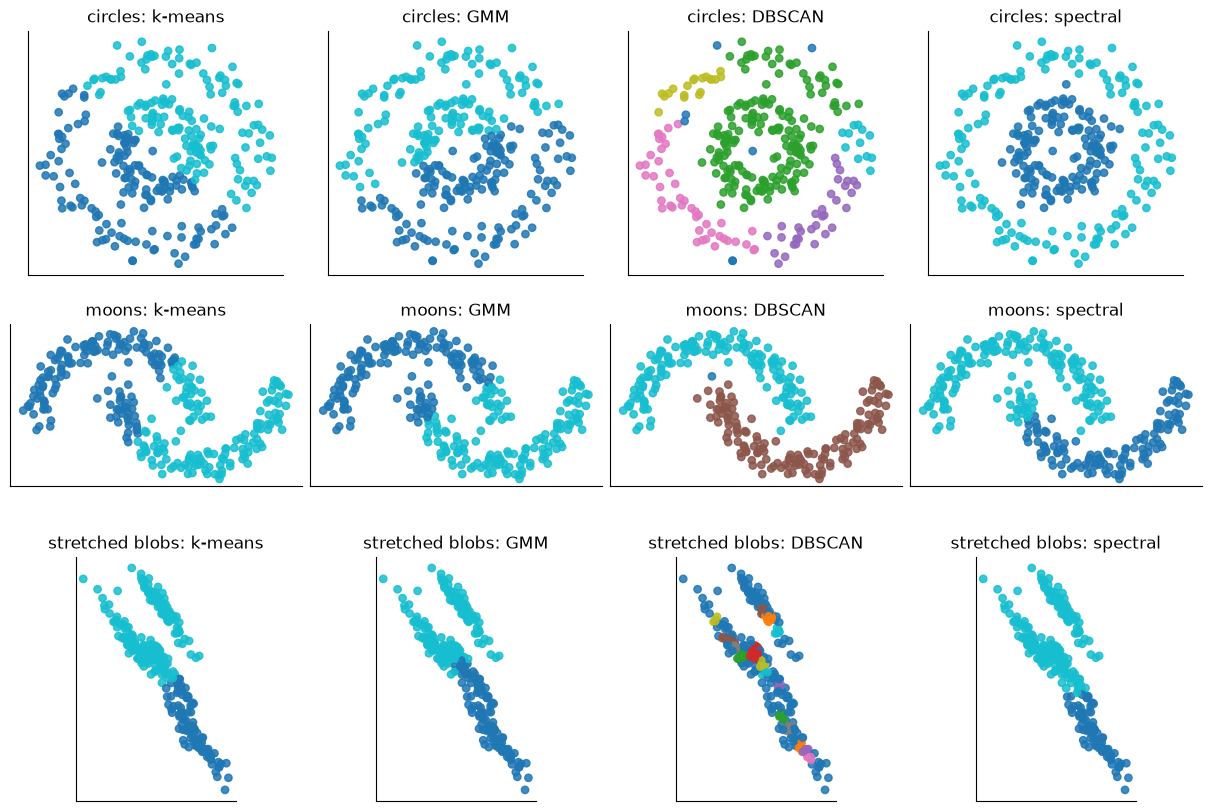

In [10]:
methods = [
    ('k-means', lambda data: KMeans(n_clusters=2, n_init=10, random_state=0).fit_predict(data)),
    ('GMM', lambda data: GaussianMixture(n_components=2, random_state=0).fit_predict(data)),
    ('DBSCAN', lambda data: DBSCAN(eps=0.18, min_samples=5).fit_predict(data)),
    ('spectral', lambda data: SpectralClustering(n_clusters=2, affinity='nearest_neighbors', random_state=0).fit_predict(data)),
]

comparison_sets = [('circles', X_circles), ('moons', X_moons), ('stretched blobs', X_aniso)]
fig, axes = plt.subplots(len(comparison_sets), len(methods), figsize=(12, 8), constrained_layout=True)

for row, (data_name, data) in enumerate(comparison_sets):
    for col, (method_name, fit_predict) in enumerate(methods):
        labels = fit_predict(data)
        show_data(data, labels, title=f'{data_name}: {method_name}', ax=axes[row, col])
plt.show()

### Discussion: match the algorithm to the data shape

1. Which algorithms assume roughly round or elliptical clusters?
2. Which algorithms can recover curved clusters?
3. Which algorithms are sensitive to hyperparameters or graph construction?
4. If these were real data with no labels, what extra evidence would you want before naming the clusters?


## Graph-based clustering

Graph-based clustering starts by turning the dataset into a **network**.

- Each observation becomes a node.
- Edges connect observations that are considered similar or nearby.
- Edge weights can represent similarity strength.

For the rest of this section, we will use the same four-cluster dataset from earlier in the notebook. This lets us compare two related views of structure:

- an **affinity matrix**, which shows pairwise connections or similarities;
- a **hierarchy**, which shows how points and clusters merge across scales.

The core modeling decision is how to build the graph:

- **k-nearest neighbor graph:** connect each point to its $k$ nearest neighbors.
- **radius graph:** connect points within distance $\epsilon$.
- **similarity graph:** connect all points with weights based on a similarity function, such as an RBF kernel.

Once we have a graph, clustering becomes a question about connectivity: which groups of nodes are strongly connected internally and weakly connected to other groups?


### Spectral clustering intuition

Spectral clustering uses eigenvectors of a graph matrix to create a new representation of the data, then clusters that representation.

Let $A$ be the adjacency or affinity matrix:

$$
A_{ij} = \text{similarity between points } i \text{ and } j.
$$

Let $D$ be the degree matrix, a diagonal matrix where

$$
D_{ii} = \sum_j A_{ij}.
$$

The unnormalized graph Laplacian is

$$
L = D - A.
$$

The Laplacian summarizes how values change over the graph. Points that are strongly connected tend to have similar eigenvector values. Spectral clustering uses the eigenvectors associated with the smallest eigenvalues of the Laplacian to embed the graph into a lower-dimensional space, then applies a method like k-means.

A useful mental model:

> Spectral clustering first changes the representation from raw coordinates to graph connectivity coordinates, then clusters in that new representation.

In this four-cluster dataset, the graph view helps us see which points are strongly connected within each cluster and which clusters are near enough that they might merge at a coarser level.


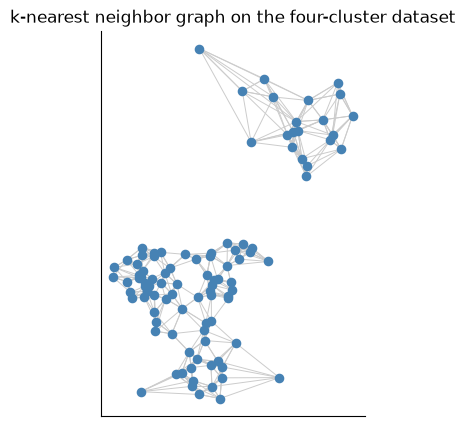

In [11]:
#| code-fold: true
from sklearn.neighbors import kneighbors_graph

# Visualize the neighborhood graph on a subset of the same dataset used below.
# The subset keeps the edge plot readable.
subset = np.random.default_rng(4).choice(len(X), size=100, replace=False)
X_graph = X[subset]
A_graph = kneighbors_graph(X_graph, n_neighbors=6, mode='connectivity', include_self=False)
rows, cols = A_graph.nonzero()

fig, ax = plt.subplots(figsize=(6, 5))
for i, j in zip(rows, cols):
    ax.plot([X_graph[i, 0], X_graph[j, 0]], [X_graph[i, 1], X_graph[j, 1]], color='0.8', linewidth=0.7, zorder=1)
ax.scatter(X_graph[:, 0], X_graph[:, 1], color='steelblue', s=35, zorder=2)
ax.set_title('k-nearest neighbor graph on the four-cluster dataset')
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect('equal', adjustable='box')
plt.show()

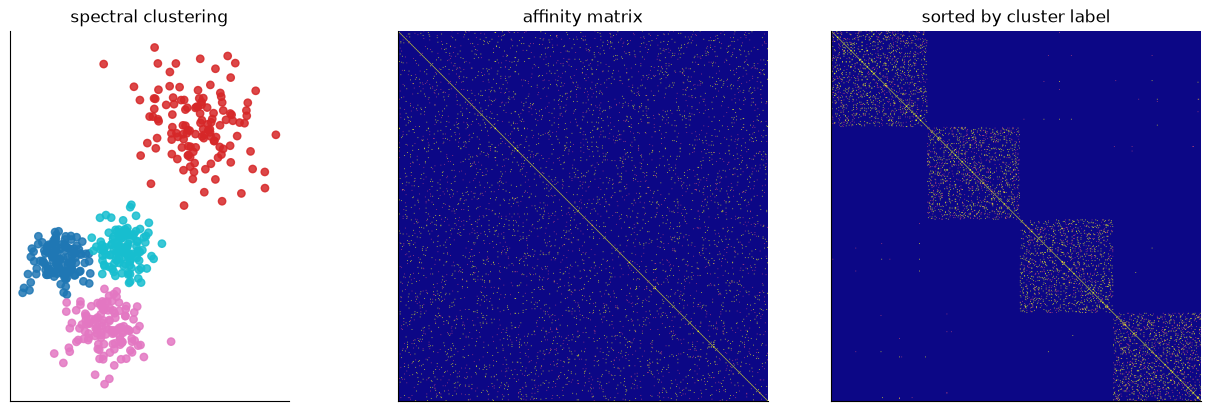

In [12]:
sc = SpectralClustering(n_clusters=4, affinity='nearest_neighbors', random_state=0)
spectral_labels = sc.fit_predict(X)
order = np.argsort(spectral_labels)
A = sc.affinity_matrix_.toarray()

fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
show_data(X, spectral_labels, title='spectral clustering', ax=axes[0])
axes[1].imshow(A, cmap='plasma')
axes[1].set_title('affinity matrix')
axes[2].imshow(A[order][:, order], cmap='plasma')
axes[2].set_title('sorted by cluster label')
for ax in axes[1:]:
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()

### How to read the affinity matrix

The affinity matrix is a picture of pairwise similarity.

- Bright entries mean two points are connected or similar.
- Dark entries mean weak or no connection.
- Before sorting, the structure may be hard to see because points are in arbitrary order.
- After sorting by cluster label, block patterns suggest groups with strong within-cluster similarity.

This matrix view is a bridge to hierarchical clustering. Both methods are asking how observations relate to one another, but they display that structure differently:

- the **affinity matrix** shows pairwise connections all at once;
- the **dendrogram** shows the order in which points and groups merge.

Spectral clustering gives one clustering for a chosen number of clusters. Hierarchical clustering, next, will let us inspect both coarse and fine cluster resolutions on this same dataset.

### Graph-based clustering discussion prompts

1. What does an edge mean in this graph?
2. How would the graph change if we increased the number of neighbors?
3. Which points or clusters appear most strongly connected?
4. How might the block structure of the affinity matrix foreshadow the dendrogram?


## Hierarchical clustering

Hierarchical clustering does not produce just one clustering. It produces a **tree of cluster merges**.

We will continue using the same four-cluster dataset from the graph and affinity matrix examples above. The goal is to see how the same pairwise structure can be represented as a hierarchy.

This dataset supports more than one resolution:

- At a **fine scale**, we may want the four visible clusters.
- At a **coarser scale**, we may want to merge nearby clusters into larger groups.
- At the highest level, all observations eventually merge into one dataset.

In agglomerative hierarchical clustering, the algorithm starts with every point as its own cluster. Then it repeatedly merges the two closest clusters until all points belong to one large cluster.

The result is shown with a **dendrogram**:

- Leaves at the bottom are individual observations or small groups.
- Branches show which clusters merge.
- The height of a merge shows how far apart the merged clusters were.
- Cutting the dendrogram at different heights gives different resolutions of clustering.

This is useful when the right number of clusters is not obvious, or when we want to inspect structure at multiple scales.


### Linkage: how do we measure distance between clusters?

Once clusters contain multiple points, we need a rule for measuring distance between clusters. This rule is called **linkage**.

Common choices:

- **Single linkage:** distance between the closest pair of points across two clusters.

$$
d(C_a, C_b) = \min_{x_i \in C_a, x_j \in C_b} \lVert x_i - x_j \rVert
$$

- **Complete linkage:** distance between the farthest pair of points across two clusters.

$$
d(C_a, C_b) = \max_{x_i \in C_a, x_j \in C_b} \lVert x_i - x_j \rVert
$$

- **Average linkage:** average pairwise distance between points in the two clusters.

$$
d(C_a, C_b) = \frac{1}{|C_a||C_b|}\sum_{x_i \in C_a}\sum_{x_j \in C_b}\lVert x_i - x_j \rVert
$$

- **Ward linkage:** merge clusters that cause the smallest increase in within-cluster variance.

For compact clusters like the four-cluster dataset above, Ward linkage is often useful because it favors groups with low within-cluster variance. Single linkage can be more sensitive to bridges or nearby boundary points because it only looks at the closest pair across clusters.


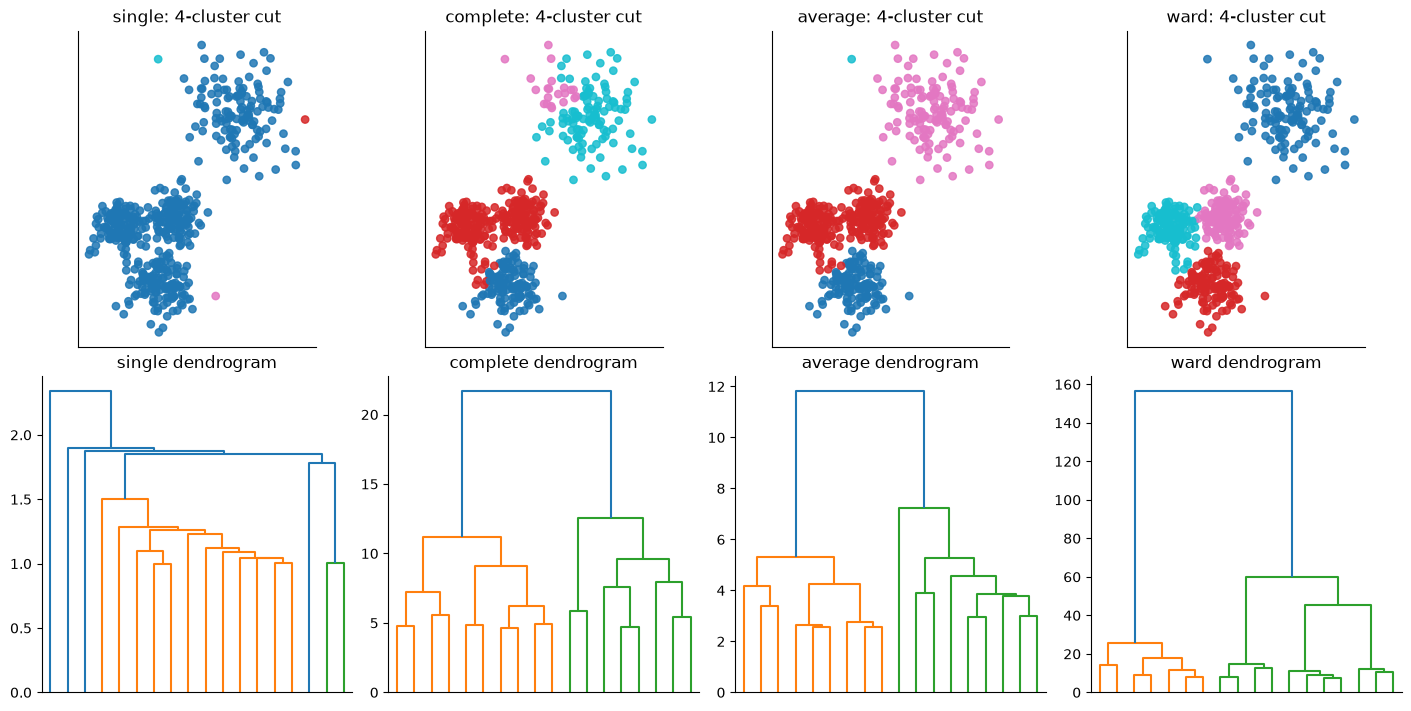

In [13]:
X_hier = X
linkage_methods = ['single', 'complete', 'average', 'ward']

fig, axes = plt.subplots(2, 4, figsize=(14, 7), constrained_layout=True)
for col, method in enumerate(linkage_methods):
    Z = linkage(X_hier, method=method)
    labels = fcluster(Z, 4, criterion='maxclust')
    show_data(X_hier, labels, title=f'{method}: 4-cluster cut', ax=axes[0, col])
    dendrogram(Z, truncate_mode='lastp', p=18, ax=axes[1, col], no_labels=True)
    axes[1, col].set_title(f'{method} dendrogram')
plt.show()

/tmp/ipykernel_1134073/2489774336.py:19: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(X[:, 0], X[:, 1], c=label, cmap=cmap, s=28, alpha=0.85)


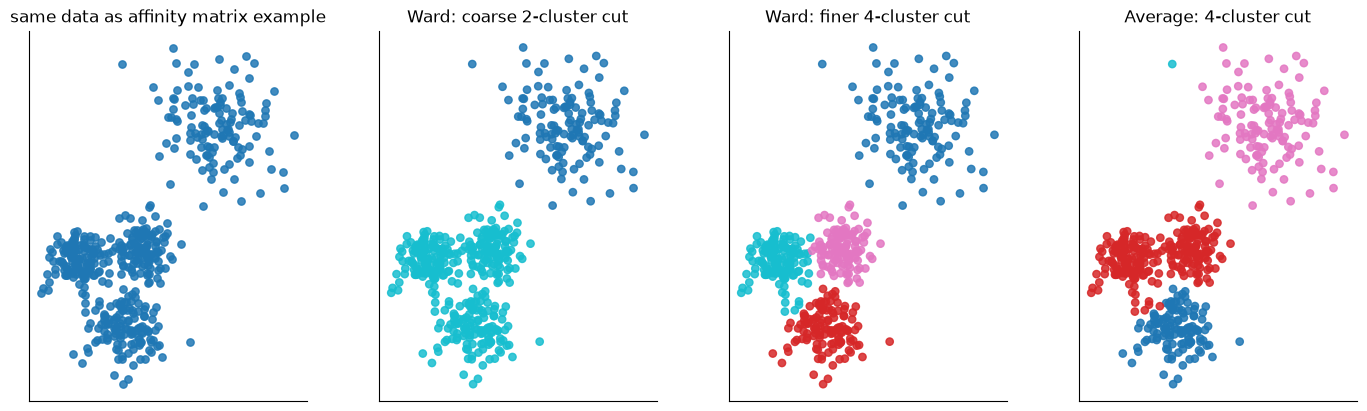

In [14]:
Z_ward = linkage(X_hier, method='ward')
Z_average = linkage(X_hier, method='average')

ward_2 = fcluster(Z_ward, 2, criterion='maxclust')
ward_4 = fcluster(Z_ward, 4, criterion='maxclust')
average_4 = fcluster(Z_average, 4, criterion='maxclust')

fig, axes = plt.subplots(1, 4, figsize=(14, 4), constrained_layout=True)
show_data(X_hier, title='same data as affinity matrix example', ax=axes[0])
show_data(X_hier, ward_2, title='Ward: coarse 2-cluster cut', ax=axes[1])
show_data(X_hier, ward_4, title='Ward: finer 4-cluster cut', ax=axes[2])
show_data(X_hier, average_4, title='Average: 4-cluster cut', ax=axes[3])
plt.show()

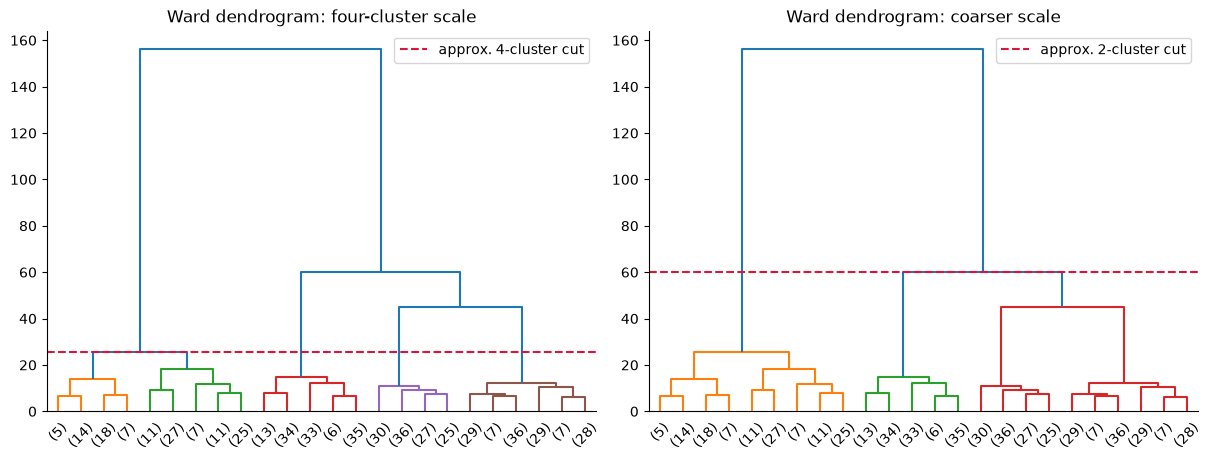

In [15]:
#| code-fold: true
height_for_4 = Z_ward[-4, 2]
height_for_2 = Z_ward[-2, 2]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
dendrogram(Z_ward, color_threshold=height_for_4, truncate_mode='lastp', p=24, ax=axes[0])
axes[0].set_title('Ward dendrogram: four-cluster scale')
axes[0].axhline(height_for_4, color='crimson', linestyle='--', label='approx. 4-cluster cut')
axes[0].legend()

dendrogram(Z_ward, color_threshold=height_for_2, truncate_mode='lastp', p=24, ax=axes[1])
axes[1].set_title('Ward dendrogram: coarser scale')
axes[1].axhline(height_for_2, color='crimson', linestyle='--', label='approx. 2-cluster cut')
axes[1].legend()
plt.show()

### How to read this dendrogram

A dendrogram is not just a decoration; it is a diagnostic.

For the four-cluster dataset, look for:

- **Fine structure:** cuts that recover the four visible groups.
- **Coarse structure:** higher cuts that merge nearby groups into larger clusters.
- **Large vertical jumps:** places where the next merge requires a much larger distance, suggesting a natural resolution.
- **Linkage behavior:** Ward tends to preserve compact groups, while single or average linkage may merge groups differently depending on boundary points and pairwise distances.

There are two common ways to turn the hierarchy into labels:

1. Choose a maximum merge distance and cut the tree at that height.
2. Choose the desired number of clusters and cut wherever that number is reached.

Both are modeling choices. The dendrogram helps make the choice visible.

### Hierarchical clustering discussion prompts

1. Where would you cut the dendrogram to recover four clusters?
2. Where would you cut it to show a coarser two-group structure?
3. Which linkage method gives clusters that best match the visual structure?
4. How does the dendrogram tell a different story than the affinity matrix?
5. What would make you choose a hierarchical view instead of one fixed clustering?


## Module summary

In this notebook, we studied clustering as a way to discover structure in data without using labels.

Key ideas covered:

- **Clustering is exploratory.** A cluster is not automatically a true category; it is a summary produced by a modeling choice.
- **Similarity matters.** Every clustering method depends on a definition of distance, density, connectivity, or probability.
- **K-means** represents clusters using centroids and works best when groups are compact and roughly spherical.
- **Silhouette scores and elbow plots** help diagnose possible values of $k$, but they do not replace domain judgment.
- **Gaussian mixture models** represent data as a mixture of probability distributions and allow soft membership.
- **DBSCAN** finds dense regions and can label points as noise, but it is sensitive to feature scaling and the choice of `eps` and `min_samples`.
- **Spectral clustering** turns data into a graph, uses an affinity matrix and graph Laplacian, and clusters a graph-based representation.
- **Affinity matrices** help reveal block structure: strong within-cluster connections and weaker between-cluster connections.
- **Hierarchical clustering** builds a tree of merges, allowing us to inspect clustering at multiple resolutions.
- **Dendrograms** show when clusters merge and help us decide whether to use a coarse or fine clustering.
- **Linkage choices** define how distances between clusters are measured; single, complete, average, and Ward linkage can tell different stories.

The recurring question is:

> What structure does this clustering method assume, and what evidence would make us trust or distrust the clusters?

## Additional materials for reading

- Scikit-learn User Guide: [Clustering](https://scikit-learn.org/stable/modules/clustering.html)
- Scikit-learn API: [KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)
- Scikit-learn API: [GaussianMixture](https://scikit-learn.org/stable/modules/generated/sklearn.mixture.GaussianMixture.html)
- Scikit-learn API: [DBSCAN](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html)
- Scikit-learn API: [SpectralClustering](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.SpectralClustering.html)
- Scikit-learn API: [AgglomerativeClustering](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html)
- SciPy docs: [Hierarchical clustering](https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html)
- Original DBSCAN paper: Ester, Kriegel, Sander, and Xu, ["A Density-Based Algorithm for Discovering Clusters in Large Spatial Databases with Noise"](https://cdn.aaai.org/KDD/1996/KDD96-037.pdf), 1996.
- Spectral clustering tutorial: von Luxburg, ["A Tutorial on Spectral Clustering"](https://arxiv.org/abs/0711.0189), 2007.
